# Limpeza e Tratamento Inicial
### O mercado de shows em São Paulo (2021–2025)

##### O projeto pretende entender o comportamento e fluxo de público em shows médio e grande em São Paulo, considerando a popularidade do nome no spotify, o genero qdo nome, o local onde ocorrem os shows, valores de ingresso e data

In [1]:
%matplotlib inline

import pandas as pd
import numpy as np
import random
import math
import re

from ydata_profiling import ProfileReport
import chardet
import unicodedata
import time

from spotipy import Spotify
from spotipy.oauth2 import SpotifyClientCredentials

import json
import base64
from dotenv import load_dotenv

import matplotlib.pyplot as plt
import seaborn as sns
from phik.report import plot_correlation_matrix

# Código para padronizar nomenclaturas

In [2]:
def normalize(nomes):
    if pd.isna(nomes):
        return None
    nomes = str(nomes)
    
    nomes = nomes.replace("’", "'")
    nomes = nomes.replace("‘", "'") 
    nomes = nomes.replace("“", '"') 
    nomes = nomes.replace("”", '"')  
    nomes = nomes.replace("–", "-")  
    nomes = nomes.replace("—", "-") 
    nomes = nomes.replace("‐", "-") 
    
    
    nomes = unicodedata.normalize('NFKD', nomes)
    nomes = ''.join(c for c in nomes if not unicodedata.combining(c))

    nomes = re.sub(r'\s+', ' ', nomes).strip().upper()
    
    return nomes

# Análise inicial das bases de dados criadas

## Base de dados de locais

In [3]:
with open('../data/external/locais.csv', 'rb') as f:
    enc = chardet.detect(f.read())
    print(enc)

locais = pd.read_csv('../data/external/locais.csv', sep= ';', encoding= 'iso8859')

print(locais.info())
locais.head()

{'encoding': 'ISO-8859-1', 'confidence': 0.73, 'language': ''}
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69 entries, 0 to 68
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Local_ID         69 non-null     object 
 1   Nome_Local       69 non-null     object 
 2   Capacidade       69 non-null     float64
 3   Categoria_Local  69 non-null     object 
 4   Tipo_Espaco      69 non-null     object 
 5   Bairro           69 non-null     object 
 6   Latitude         69 non-null     object 
 7   Longitude        69 non-null     object 
dtypes: float64(1), object(7)
memory usage: 4.4+ KB
None


,Local_ID,Nome_Local,Capacidade,Categoria_Local,Tipo_Espaco,Bairro,Latitude,Longitude
0,L025,Centro Cultural São Paulo,2.0,Médias Casas,Teatro E Casa De Espetáculos,Vergueiro,'-23.5708,'-46.6403
1,L033,Centro de Eventos São Luís,2.5,Médias Casas,Centro De Exposições,Bela Vista,'-23.5522,'-46.6594
2,L034,Sambodramo Anhembi,2.5,Médias Casas,Casa De Shows,Santana,'-23.51611,'-46.64320
3,L007,Komplexo Tempo,3.0,Médias Casas,Casa De Shows,Mooca,'-23.57034,'-46.60027
4,L012,Espaço Leste Music,3.0,Médias Casas,Casa De Shows,Zona Leste,'-23.59208,'-46.47236


In [4]:
# Como a criação dessa base foi manual no excel, para os valores de latitude e Longitude materem o formato útil inclue o ', que será retirado aqui
locais['Latitude'] = locais['Latitude'].str.lstrip("'")
locais['Longitude'] = locais['Longitude'].str.lstrip("'")

locais['nome_local'] = locais['Nome_Local'].apply(normalize)
locais['Categoria_Local'] = locais['Categoria_Local'].apply(normalize)
locais['Tipo_Espaco'] = locais['Tipo_Espaco'].apply(normalize)
locais['Bairro'] = locais['Bairro'].apply(normalize)
locais['Capacidade'] = locais['Capacidade']*1000

locais = locais.drop(['Nome_Local'], axis = 1)

pr_locais = ProfileReport(locais, title='Profiling Report of Locais Data Base')
pr_locais

# Como essa base de dados foi construída manualmente, foram tomados todos os cuidados para não haver dados em branco nela, tentando mantê-la de forma mais limpa e com os dados o mais claros e simplificados possível. Assim, apenas criarei a matriz de correlação para decisão de redução e  limpeza da base.

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|███████████████████████████████████████████████████████████████████████████████████| 8/8 [00:00<00:00, 425.95it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

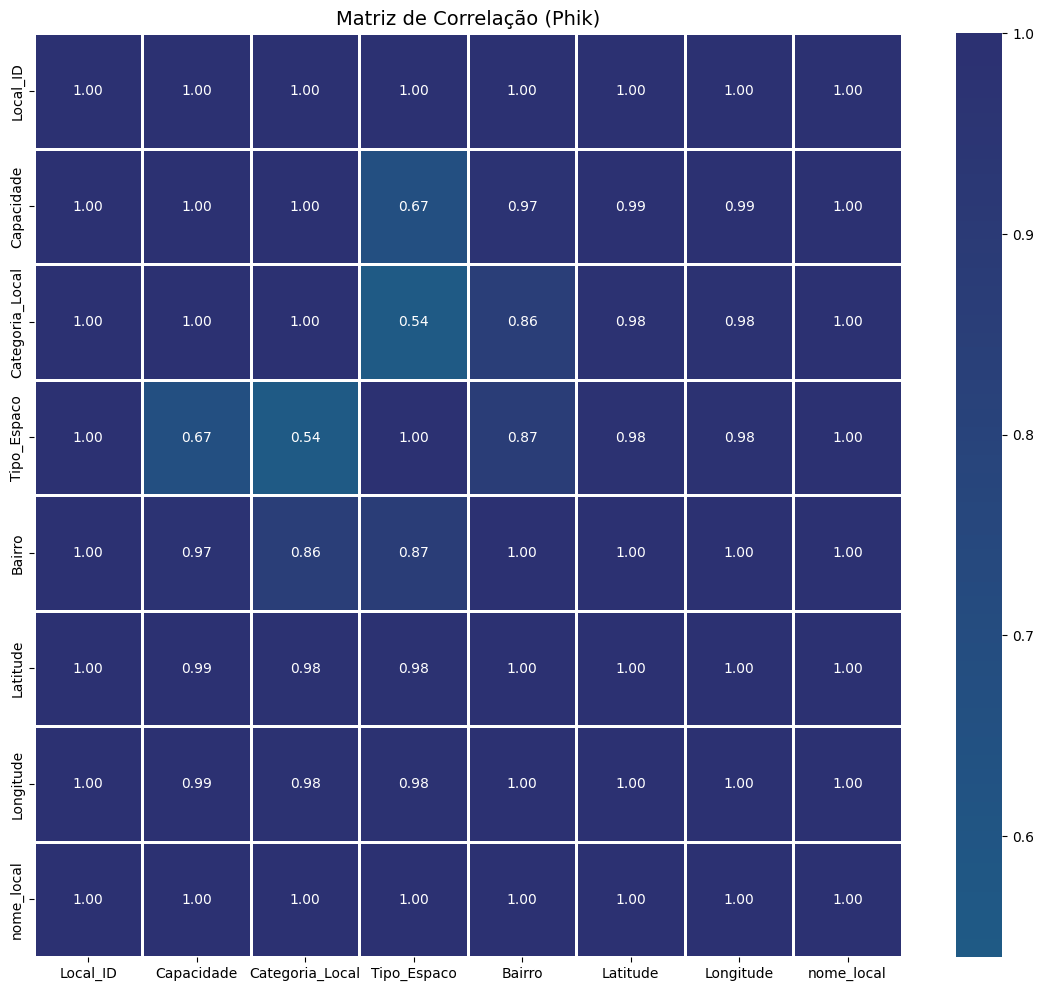

In [5]:
# Como são muitas variáveis categóricas utilizarei o método de análise phik

phik_corr = locais.phik_matrix(interval_cols=[])

plt.figure(figsize=(14, 12))
sns.heatmap(
    phik_corr,
    annot=True,
    fmt='.2f',
    cmap='crest',
    center=0,
    linewidths=2,
    linecolor='#FFFFFF'
)
plt.title('Matriz de Correlação (Phik)', fontsize=14)
plt.show()

# Para manter a base mais 'clean' considerando a matriz anterior, excluirei bairro e local_id, considerando que são variáveis duplicadas. Posteriormente excluirei também a Capacidade, após fazer cálculos para construção da base final.

locais = locais.drop(['Local_ID', 'Bairro'], axis = 1)

locais.to_csv('../data/raw/locais_limpo.csv', index=False)

## Base de dados inicial de shows

In [6]:
with open('../data/external/shows.csv', 'rb') as f:
    enc = chardet.detect(f.read())
    print(enc)

shows = pd.read_csv('../data/external/shows.csv', encoding='utf-8')
print(shows.info())
shows.head()

{'encoding': 'UTF-8-SIG', 'confidence': 1.0, 'language': ''}
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10620 entries, 0 to 10619
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   artista  10620 non-null  object
 1   data     10620 non-null  object
 2   ano      10620 non-null  int64 
 3   local    10605 non-null  object
 4   cidade   10620 non-null  object
 5   estado   10620 non-null  object
dtypes: int64(1), object(5)
memory usage: 497.9+ KB
None


,artista,data,ano,local,cidade,estado
0,Pitty,2021-01-15,2021,Private Venue,São Paulo,São Paulo
1,Nirvana Experience (ex-Hormoaning),2021-01-16,2021,Relicário Rock Bar,São Paulo,São Paulo
2,Ivete Sangalo,2021-02-03,2021,Conversa com Bial,São Paulo,São Paulo
3,Pitty,2021-02-05,2021,Private Venue,São Paulo,São Paulo
4,Pabllo Vittar,2021-02-06,2021,Altas Horas,São Paulo,São Paulo


In [7]:
# Transformar a data para o formato correto
shows['data'] = pd.to_datetime(shows['data'], errors='coerce')

shows['nome_local'] = shows['local'].apply(normalize)
shows['nome'] = shows['artista'].apply(normalize)

# Existem dados em branco apenas na coluna de local em 15 linhas
shows[shows['local'].isnull()]

# Substituição dos valores nulos pela moda em relação acoluna artista
fill_mode = lambda x: x.fillna(x.mode()[0])
shows['local'] = shows.groupby('artista')['local'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else 'Desconhecido')
)
shows.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10620 entries, 0 to 10619
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   artista     10620 non-null  object        
 1   data        10620 non-null  datetime64[ns]
 2   ano         10620 non-null  int64         
 3   local       10620 non-null  object        
 4   cidade      10620 non-null  object        
 5   estado      10620 non-null  object        
 6   nome_local  10605 non-null  object        
 7   nome        10620 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(6)
memory usage: 663.9+ KB


In [8]:
pr_shows = ProfileReport(shows, title='Profiling Report of Shows Data Base')
pr_shows

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|███████████████████████████████████████████████████████████████████████████████████| 8/8 [00:00<00:00, 114.04it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [9]:
# Como serão considerados apenas shows grandes e médios para a análise do trabalho, podemos considerar praticamente impossível o mesmo artista fazer um show em um mesmo local em um mesmo dia. Assim, serão apagadas as linhas duplicadas dessa base.

shows = shows.drop_duplicates()

# Também apagarei shows que ocorrerão em outros municípios que não São Paulo capital.

shows = shows[shows['cidade'] == 'São Paulo']

# Essa é uma base de dados fato, portanto os conjuntos de valores nela são praticamente únicos e apenas retirarei da análise as colunas de estado e cidade, que utilizei apenas para conferência na construção. Como normalizei o nome do local, também o apagarei não normalizado.

shows = shows.drop(['estado', 'cidade', 'local'], axis = 1)

shows.to_csv('../data/raw/shows_limpo.csv', index=True)

In [10]:
shows.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10459 entries, 0 to 10619
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   artista     10459 non-null  object        
 1   data        10459 non-null  datetime64[ns]
 2   ano         10459 non-null  int64         
 3   nome_local  10444 non-null  object        
 4   nome        10459 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(3)
memory usage: 490.3+ KB


In [11]:
shows.head()

,artista,data,ano,nome_local,nome
0,Pitty,2021-01-15,2021,PRIVATE VENUE,PITTY
1,Nirvana Experience (ex-Hormoaning),2021-01-16,2021,RELICARIO ROCK BAR,NIRVANA EXPERIENCE (EX-HORMOANING)
2,Ivete Sangalo,2021-02-03,2021,CONVERSA COM BIAL,IVETE SANGALO
3,Pitty,2021-02-05,2021,PRIVATE VENUE,PITTY
4,Pabllo Vittar,2021-02-06,2021,ALTAS HORAS,PABLLO VITTAR


## Base de Artistas
Criada com o API do Spotify, rodei o código 4 vezes para incremento.

In [12]:
with open('../data/external/artistas.csv', 'rb') as f:
    enc = chardet.detect(f.read())
    print(enc)
    
artistas = pd.read_csv('../data/external/artistas.csv', sep = ';')
print(artistas.info())
artistas.head()

{'encoding': 'UTF-8-SIG', 'confidence': 1.0, 'language': ''}
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4757 entries, 0 to 4756
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   nome          4757 non-null   object
 1   id_spotify    4757 non-null   object
 2   generos       4757 non-null   object
 3   popularidade  4757 non-null   int64 
 4   seguidores    4757 non-null   int64 
 5   imagem        4757 non-null   object
 6   fonte         4757 non-null   object
dtypes: int64(2), object(5)
memory usage: 260.3+ KB
None


,nome,id_spotify,generos,popularidade,seguidores,imagem,fonte
0,Arijit Singh,4YRxDV8wJFPHPTeXepOstw,"hindi pop, bollywood, desi, bangla pop",90,165739069,https://i.scdn.co/image/ab6761610000e5eb5ba2d7...,GENRE_1
1,Taylor Swift,06HL4z0CvFAxyc27GXpf02,pop,100,146601270,https://i.scdn.co/image/ab6761610000e5ebe2e8e7...,GENRE_1
2,Ed Sheeran,6eUKZXaKkcviH0Ku9w2n3V,soft pop,89,123163279,https://i.scdn.co/image/ab6761610000e5ebd55c95...,GENRE_1
3,Billie Eilish,6qqNVTkY8uBg9cP3Jd7DAH,pop,92,119521349,https://i.scdn.co/image/ab6761610000e5eb4a21b4...,GENRE_1
4,The Weeknd,1Xyo4u8uXC1ZmMpatF05PJ,pop,95,113983998,https://i.scdn.co/image/ab6761610000e5eb9e5289...,GENRE_2


In [13]:
artistas['nome'] = artistas['nome'].apply(normalize)
artistas['generos'] = artistas['generos'].apply(normalize)

#Os dados de gêneros em branco foram corrigidos com ajuda de ia manualmente.

pr_artistas = ProfileReport(artistas, title='Profiling Report of Artistas Data Base')
pr_artistas

#Assim como a base anterior, essa base é única.

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|████████████████████████████████████████████████████████████████████████████████████| 7/7 [00:00<00:00, 60.33it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

## Base de Calendário

In [14]:
calend = pd.read_csv('../data/external/calendario_sp.csv')

print(calend.info())
calend.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   data                2200 non-null   object 
 1   ano                 2200 non-null   int64  
 2   dia_semana          2200 non-null   object 
 3   nome_feriado        90 non-null     object 
 4   tipo_dia            2200 non-null   object 
 5   temperature_2m_max  1785 non-null   float64
 6   temperature_2m_min  1785 non-null   float64
 7   precipitation_sum   1785 non-null   float64
 8   weathercode         1785 non-null   float64
 9   descricao_clima     1785 non-null   object 
dtypes: float64(4), int64(1), object(5)
memory usage: 172.0+ KB
None


,data,ano,dia_semana,nome_feriado,tipo_dia,temperature_2m_max,temperature_2m_min,precipitation_sum,weathercode,descricao_clima
0,2021-01-01,2021,Sexta-feira,Confraternização mundial,Feriado Nacional,26.2,18.4,10.5,63.0,Chuva moderada
1,2021-01-02,2021,Sábado,NaN,Fim de semana,23.4,18.3,5.0,61.0,Chuva leve
2,2021-01-03,2021,Domingo,NaN,Fim de semana,24.9,17.2,3.6,53.0,Chuvisco moderado
3,2021-01-04,2021,Segunda-feira,NaN,Dia útil,26.8,17.2,2.4,61.0,Chuva leve
4,2021-01-05,2021,Terça-feira,NaN,Dia útil,28.6,17.7,4.7,61.0,Chuva leve


In [15]:
# Os dados em branco da coluna 'nome_feriado' não precisam ser tratados, uma vez que dependem de existir um feriado na data e, caso não o haja, ela realmente ficará em branco. Entretanto, os dados referentes ao clima podemos substituir separando em dois grupos de dados: o primeiro referente a dados numéricos de temperatura, precipitação e o código, podemos gerenciar pela média em relação a anos anteriores, considerando períodos mensais semelhantes; já em relação à descrição, podemos fazê-la considerando o resultado da média do código calculada, utilizando-se a moda para cálculo.

calend['data'] = pd.to_datetime(calend['data'], format='%Y-%m-%d', errors='coerce')
calend['num_mes'] = calend['data'].dt.month

meses = {
    1: 'JANEIRO',
    2: 'FEVEREIRO',
    3: 'MARÇO',
    4: 'ABRIL',
    5: 'MAIO',
    6: 'JUNHO',
    7: 'JULHO',
    8: 'AGOSTO',
    9: 'SETEMBRO',
    10: 'OUTUBRO',
    11: 'NOVEMBRO',
    12: 'DEZEMBRO'
}
calend['mes'] = calend['num_mes'].map(meses)

calend.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   data                2200 non-null   datetime64[ns]
 1   ano                 2200 non-null   int64         
 2   dia_semana          2200 non-null   object        
 3   nome_feriado        90 non-null     object        
 4   tipo_dia            2200 non-null   object        
 5   temperature_2m_max  1785 non-null   float64       
 6   temperature_2m_min  1785 non-null   float64       
 7   precipitation_sum   1785 non-null   float64       
 8   weathercode         1785 non-null   float64       
 9   descricao_clima     1785 non-null   object        
 10  num_mes             2200 non-null   int32         
 11  mes                 2200 non-null   object        
dtypes: datetime64[ns](1), float64(4), int32(1), int64(1), object(5)
memory usage: 197.8+ KB


In [16]:
cols = ['temperature_2m_max', 'temperature_2m_min', 'precipitation_sum', 'weathercode']

calend[cols] = calend.groupby(['mes'])[cols].transform(lambda x: x.fillna(x.mean()))

calend['temperatura_media'] = (calend['temperature_2m_max'] + calend['temperature_2m_min'])/2
calend = calend.drop(['temperature_2m_max','temperature_2m_min'], axis = 1)

calend['descricao_clima'] = calend.groupby(['weathercode'])['descricao_clima'].fillna(pd.Series.mode)
calend['dia_semana'] = calend['dia_semana'].apply(normalize)
calend['nome_feriado'] = calend['nome_feriado'].apply(normalize)
calend['tipo_dia'] = calend['tipo_dia'].apply(normalize)
calend['descricao_clima'] = calend['descricao_clima'].apply(normalize)

calend.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   data               2200 non-null   datetime64[ns]
 1   ano                2200 non-null   int64         
 2   dia_semana         2200 non-null   object        
 3   nome_feriado       90 non-null     object        
 4   tipo_dia           2200 non-null   object        
 5   precipitation_sum  2200 non-null   float64       
 6   weathercode        2200 non-null   float64       
 7   descricao_clima    2200 non-null   object        
 8   num_mes            2200 non-null   int32         
 9   mes                2200 non-null   object        
 10  temperatura_media  2200 non-null   float64       
dtypes: datetime64[ns](1), float64(3), int32(1), int64(1), object(5)
memory usage: 180.6+ KB


In [17]:
pr_calend = ProfileReport(calend, title='Profiling Report of Calendario Data Base')
pr_calend

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|█████████████████████████████████████████████████████████████████████████████████| 11/11 [00:00<00:00, 416.28it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [18]:
#Dimensaionalisar a base de dados (data tem mais de uma entrada)
calend = (
    calend
    .groupby(['data', 'ano'], as_index=False)
    .agg({
        'dia_semana': 'first',
        'nome_feriado': 'first',
        'tipo_dia': 'first',
        'precipitation_sum': 'mean',
        'weathercode': 'first',
        'descricao_clima': 'first',
        'num_mes': 'first',
        'mes': 'first', 
        'temperatura_media': 'mean'
    })
)

C:\Users\marin\anaconda3\envs\jupyter_env\Lib\site-packages\phik\data_quality.py:59: UserWarning: The number of unique values of variable data is large: 2191. Are you sure this is not an interval variable? Analysis for pairs of variables including data can be slow.
  warnings.warn(


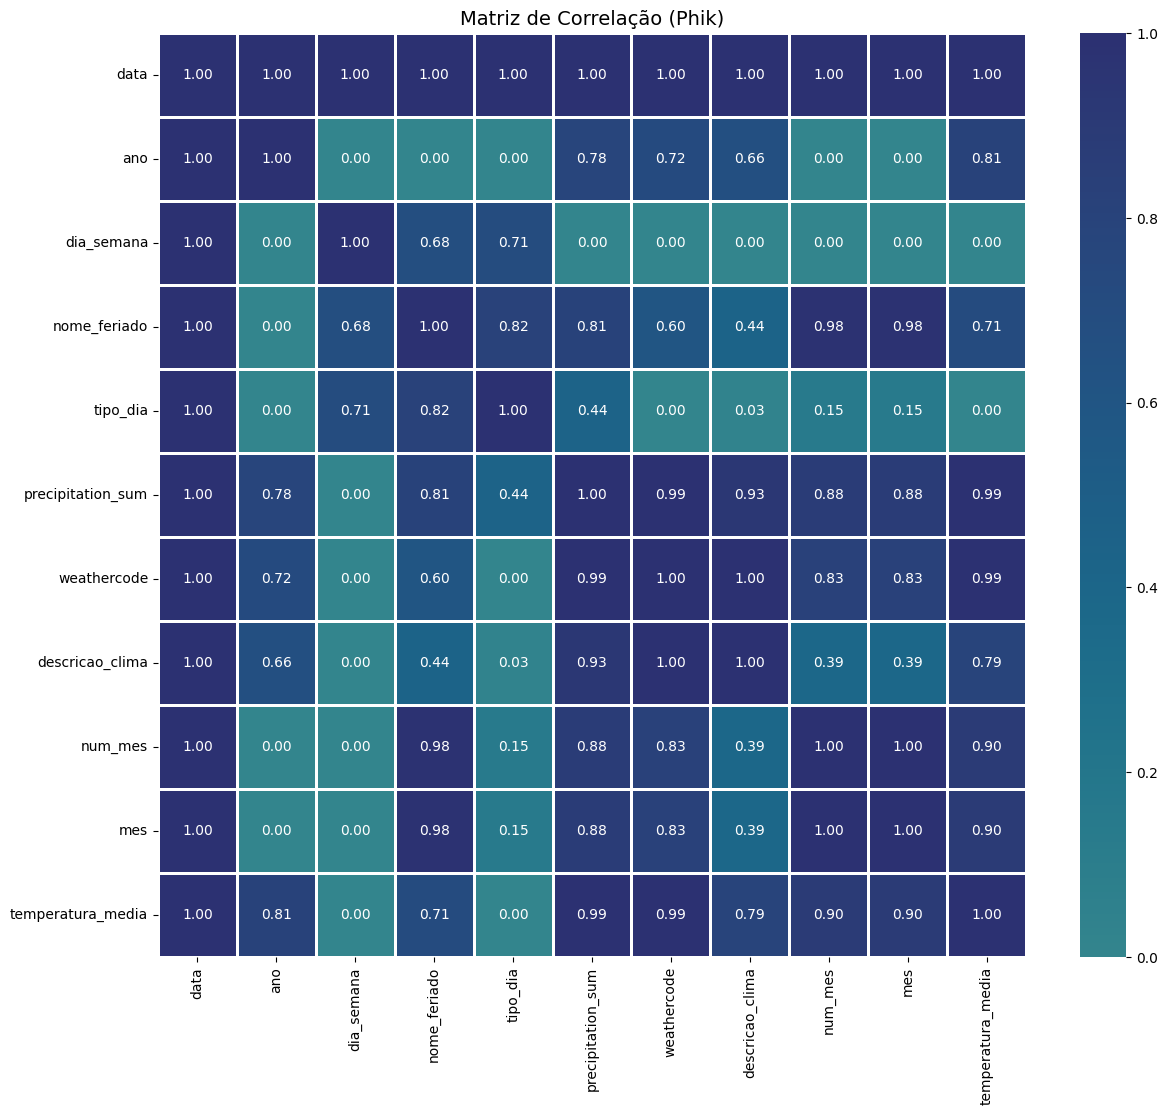

In [19]:
# Como são muitas variáveis categóricas utilizarei o método de análise phik

phik_corr = calend.phik_matrix(interval_cols=[])

plt.figure(figsize=(14, 12))
sns.heatmap(
    phik_corr,
    annot=True,
    fmt='.2f',
    cmap='crest',
    center=0,
    linewidths=2,
    linecolor='#FFFFFF'
)
plt.title('Matriz de Correlação (Phik)', fontsize=14)
plt.show()

In [20]:
# Excluirei o nome do feriado, uma vez que entendo que as variáveis tipo_dia e num_mes estão duplicando. Entre as variáveis de clima, percebemos uma forte relação entre todas, considerando wethercode e descricao_clima as de melhor entendimento. Manterei apenas a segunda para análise, uma vez que essa dá significado em palavras para os números da primeira.

calend = calend.drop(['nome_feriado', 'precipitation_sum', 'weathercode', 'num_mes', 'temperatura_media'], axis = 1)

calend.to_csv('../data/raw/calendario_tratado.csv', index=True)

## Base de Setores

In [21]:
setores = pd.read_csv('../data/external/setores.csv', sep = ';', encoding= 'iso8859')

print(setores.info())
setores.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Setor_id         25 non-null     object
 1   Nome_Setor       25 non-null     object
 2   Categoria_Setor  25 non-null     object
dtypes: object(3)
memory usage: 732.0+ bytes
None


,Setor_id,Nome_Setor,Categoria_Setor
0,S001,Pista,Comum
1,S002,Pista Premium,VIP
2,S003,Camarote,Luxo
3,S004,Cadeira Inferior,Intermediário
4,S005,Cadeira Inferior Visão Parcial,Comum


In [22]:
setores['Categoria_Setor'].unique()

setores['Nome_Setor'] = setores['Nome_Setor'].apply(normalize)
setores['Categoria_Setor'] = setores['Categoria_Setor'].apply(normalize)

# Base de dados criada manualmente, e, portanto, não precisa de mais tratamento.

## Base de Festivias

Base criada manualmente para enriquecer a análise.

In [23]:
fest = pd.read_csv('../data/external/festivais.csv', sep = ';', encoding = 'iso8859')

print(fest.info())
fest.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Festival    96 non-null     object
 1   Local       96 non-null     object
 2   Data        96 non-null     object
 3   Ano         96 non-null     int64 
 4   Headliners  96 non-null     object
dtypes: int64(1), object(4)
memory usage: 3.9+ KB
None


,Festival,Local,Data,Ano,Headliners
0,Coala Festival,Memorial da América Latina,11/09/2021,2021,"Maria Bethânia, Alceu Valença"
1,Coala Festival,Memorial da América Latina,12/09/2021,2021,"Gal Costa, Black Alien"
2,Lollapalooza,Autódromo de Interlagos,25/03/2022,2022,The Strokes
3,Lollapalooza,Autódromo de Interlagos,26/03/2022,2022,Miley Cyrus
4,Lollapalooza,Autódromo de Interlagos,27/03/2022,2022,Foo Fighters


In [24]:
fest['nome_local'] = fest['Local'].apply(normalize)
fest['festival'] = fest['Festival'].apply(normalize)
fest['headliners'] = fest['Headliners'].apply(normalize)

fest = fest.dropna(subset=['Ano'])
fest['ano'] = fest['Ano'].astype(int)

# Transformar a data para o formato correto
fest['data'] = pd.to_datetime(fest['Data '], dayfirst=True, errors='coerce')

fest.head()

,Festival,Local,Data,Ano,Headliners,nome_local,festival,headliners,ano,data
0,Coala Festival,Memorial da América Latina,11/09/2021,2021,"Maria Bethânia, Alceu Valença",MEMORIAL DA AMERICA LATINA,COALA FESTIVAL,"MARIA BETHANIA, ALCEU VALENCA",2021,2021-09-11
1,Coala Festival,Memorial da América Latina,12/09/2021,2021,"Gal Costa, Black Alien",MEMORIAL DA AMERICA LATINA,COALA FESTIVAL,"GAL COSTA, BLACK ALIEN",2021,2021-09-12
2,Lollapalooza,Autódromo de Interlagos,25/03/2022,2022,The Strokes,AUTODROMO DE INTERLAGOS,LOLLAPALOOZA,THE STROKES,2022,2022-03-25
3,Lollapalooza,Autódromo de Interlagos,26/03/2022,2022,Miley Cyrus,AUTODROMO DE INTERLAGOS,LOLLAPALOOZA,MILEY CYRUS,2022,2022-03-26
4,Lollapalooza,Autódromo de Interlagos,27/03/2022,2022,Foo Fighters,AUTODROMO DE INTERLAGOS,LOLLAPALOOZA,FOO FIGHTERS,2022,2022-03-27


In [25]:
fest = fest.drop(['Local', 'Festival', 'Headliners', 'Data ', 'Ano'], axis = 1)

# Nessa base eu apenas apaguei a coluna original de local, como tratamento.
# Utilizarei essa base inicialmente para retirar os shows que aconteceram durante o jogo da NFL no Brasil, uma vez que o público nestes eventos não tem como principal foco o show musical, mas sim o esportivo.

# -------------------------------------------------------------------------------------
# Tratar e transformar as bases carregadas

## Tratamento inicial para a base de Shows
Criação da base de dados de shows com a interação entre essa base e a base de locais para seleção dos shows em locais com público-alvo maior ou igual a 2000 presentes (shows médios e grandes).

In [26]:
shows_locais = shows.merge(locais, how ='inner', on= 'nome_local')
shows_locais.head()

,artista,data,ano,nome_local,nome,Capacidade,Categoria_Local,Tipo_Espaco,Latitude,Longitude
0,Aquiles Priester,2021-08-29,2021,TOM BRASIL,AQUILES PRIESTER,4000.0,MEDIAS CASAS,CASA DE SHOWS,-23.602102,-46.687800
1,Zeca Baleiro,2021-10-02,2021,TOM BRASIL,ZECA BALEIRO,4000.0,MEDIAS CASAS,CASA DE SHOWS,-23.602102,-46.687800
2,Vanessa da Mata,2021-10-23,2021,TOM BRASIL,VANESSA DA MATA,4000.0,MEDIAS CASAS,CASA DE SHOWS,-23.602102,-46.687800
3,Ana Carolina,2021-11-06,2021,TOM BRASIL,ANA CAROLINA,4000.0,MEDIAS CASAS,CASA DE SHOWS,-23.602102,-46.687800
4,Fabio Lione,2021-11-19,2021,TOM BRASIL,FABIO LIONE,4000.0,MEDIAS CASAS,CASA DE SHOWS,-23.602102,-46.687800


In [27]:
shows_locais.info()
shows_locais.to_csv('../data/raw/shows_locais.csv', index=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3077 entries, 0 to 3076
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   artista          3077 non-null   object        
 1   data             3077 non-null   datetime64[ns]
 2   ano              3077 non-null   int64         
 3   nome_local       3077 non-null   object        
 4   nome             3077 non-null   object        
 5   Capacidade       3077 non-null   float64       
 6   Categoria_Local  3077 non-null   object        
 7   Tipo_Espaco      3077 non-null   object        
 8   Latitude         3077 non-null   object        
 9   Longitude        3077 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(7)
memory usage: 240.5+ KB


In [28]:
# Para reduzir entradas outliers na base anterior, como shows de artistas com poucos seguidores ou baixa popularidade em locais desproporcionalmente grandes, significando, provavelmente, uma abertura para um show de uma banda maior ou um festival. Farei um comparativo entre a base de artistas e a anterior, focando em shows no mesmo dia e no mesmo local, mantendo os artistas com mais alta de popularidade.

shows_locais_artistas = shows_locais.merge(artistas, how ='left', on = 'nome')

shows_tratado = (shows_locais_artistas
                 .sort_values(by = ['seguidores', 'popularidade'], ascending=False)
                 .drop_duplicates(subset=['nome', 'data', 'nome_local'], keep='first')
                 .copy())

shows_tratado.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3070 entries, 1042 to 3070
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   artista          3070 non-null   object        
 1   data             3070 non-null   datetime64[ns]
 2   ano              3070 non-null   int64         
 3   nome_local       3070 non-null   object        
 4   nome             3070 non-null   object        
 5   Capacidade       3070 non-null   float64       
 6   Categoria_Local  3070 non-null   object        
 7   Tipo_Espaco      3070 non-null   object        
 8   Latitude         3070 non-null   object        
 9   Longitude        3070 non-null   object        
 10  id_spotify       1382 non-null   object        
 11  generos          1382 non-null   object        
 12  popularidade     1382 non-null   float64       
 13  seguidores       1382 non-null   float64       
 14  imagem           1382 non-null   object   

In [29]:
shows_tratado.head()

,artista,data,ano,nome_local,nome,Capacidade,Categoria_Local,Tipo_Espaco,Latitude,Longitude,id_spotify,generos,popularidade,seguidores,imagem,fonte
1042,Taylor Swift,2023-11-24,2023,ALLIANZ PARQUE,TAYLOR SWIFT,45000.0,ARENAS E ESTADIOS,ESTADIO MULTIUSO,-23.5276207,-46.6784662,06HL4z0CvFAxyc27GXpf02,POP,100.0,146601270.0,https://i.scdn.co/image/ab6761610000e5ebe2e8e7...,GENRE_1
1045,Taylor Swift,2023-11-25,2023,ALLIANZ PARQUE,TAYLOR SWIFT,45000.0,ARENAS E ESTADIOS,ESTADIO MULTIUSO,-23.5276207,-46.6784662,06HL4z0CvFAxyc27GXpf02,POP,100.0,146601270.0,https://i.scdn.co/image/ab6761610000e5ebe2e8e7...,GENRE_1
1046,Taylor Swift,2023-11-26,2023,ALLIANZ PARQUE,TAYLOR SWIFT,45000.0,ARENAS E ESTADIOS,ESTADIO MULTIUSO,-23.5276207,-46.6784662,06HL4z0CvFAxyc27GXpf02,POP,100.0,146601270.0,https://i.scdn.co/image/ab6761610000e5ebe2e8e7...,GENRE_1
460,Billie Eilish,2023-03-24,2023,AUTODROMO DE INTERLAGOS,BILLIE EILISH,100000.0,ARENAS E ESTADIOS,AREA EXTERNA PARA EVENTOS,-23.7000,-46.6972,6qqNVTkY8uBg9cP3Jd7DAH,POP,92.0,119521349.0,https://i.scdn.co/image/ab6761610000e5eb4a21b4...,GENRE_1
1017,The Weeknd,2023-10-10,2023,ALLIANZ PARQUE,THE WEEKND,45000.0,ARENAS E ESTADIOS,ESTADIO MULTIUSO,-23.5276207,-46.6784662,1Xyo4u8uXC1ZmMpatF05PJ,POP,95.0,113983998.0,https://i.scdn.co/image/ab6761610000e5eb9e5289...,GENRE_2


In [30]:
shows_tratado = shows_tratado.merge(fest, how = 'left', on = ['data', 'nome_local', 'ano'])

shows_tratado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3070 entries, 0 to 3069
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   artista          3070 non-null   object        
 1   data             3070 non-null   datetime64[ns]
 2   ano              3070 non-null   int64         
 3   nome_local       3070 non-null   object        
 4   nome             3070 non-null   object        
 5   Capacidade       3070 non-null   float64       
 6   Categoria_Local  3070 non-null   object        
 7   Tipo_Espaco      3070 non-null   object        
 8   Latitude         3070 non-null   object        
 9   Longitude        3070 non-null   object        
 10  id_spotify       1382 non-null   object        
 11  generos          1382 non-null   object        
 12  popularidade     1382 non-null   float64       
 13  seguidores       1382 non-null   float64       
 14  imagem           1382 non-null   object 

In [31]:
# Apagando eventos não musicais
shows_tratado = shows_tratado[~shows_tratado['festival'].isin(['NFL BRASIL', 'GP FORMULA 1', 'FESTIVAL DE MOTOS DE INTERLAGOS', 'SAO PAULO HORROR EXPO', 'ROLEX 6 HORAS', 'FINAL DA KINGS LEAGUE BRASIL', 'S.I.N. FESTIVAL', 'FINAL DO CAMPEONATO PAULISTA', 'TIKTOK AWARDS'])]

# Para o tratamento dos dados faltosos vindos do API do Spotify, pegarei a listagem de nomes e puxarei esses dados usando o mesmo código.
sem_dados = shows_tratado[shows_tratado['generos'].isnull()]['artista'].unique()
consulta = []
for i in sem_dados:
    cons = f'{i}'
    consulta.append(cons)

print(consulta)

['Aquiles Priester', 'Zeca Baleiro', 'Fabio Lione', 'Alirio Netto', 'Boate Azul Ao Vivo', 'Paulo Ricardo', 'Raquel', 'Gab Ferreira', 'Terno Rei', 'Recayd Mob', 'Danny Bond', 'Kika Boom', 'Kerli', 'Greyson Chance', 'Violet Chachki', 'Gilmelândia', 'Tainá Costa', 'Karol Conká', 'MC WM', 'POCAH', 'MC Kekel', 'Lexa', 'Project46', 'Alexisonfire', 'The Raulis', 'Academia da Berlinda', 'Supercombo', 'Dead Fish', 'BRAZA', 'Lockdown', 'Emperor', 'Kamasi Washington', 'Fresno', 'Lucas Inutilismo', 'Allen Key', 'Shaman', 'Sinaya', 'Krisiun', 'Max & Iggor Cavalera', 'PRISCILLA', 'Potyguara Bardo', 'Sampa the Great', 'Rodrigo Amarante', 'Mayra Andrade', 'Andreas Kisser', 'Oficina G3', 'Aliados', 'Marcão Britto & Thiago Castanho Charlie Brown Jr.', 'DPR LIVE', 'DPR CREAM', 'DPR REM', 'Paula Toller', 'Ratos de Porão', 'Molho Negro', 'Crypta', 'Black Pantera', 'Merca Bae', 'Sangre Nueva', 'FBC', 'Mac Júlia', 'Massacration', 'Operador', 'Mia Badgyal', 'Behemoth', 'Arch Enemy', 'Nervosa', 'Kings of Conve

In [ ]:
CLIENTES = [ ('**', '**') ]
LIMIT = 50
MAX_PAGES = 10
PARCIAL = 'parcial_trat.json'
CSV_FINAL = 'artistas_trat.csv'

def autenticar(indice):
    cid, secret = CLIENTES[indice]
    print(f'\n🔐 Iniciando API ID: {cid[:10]}...')
    return Spotify( auth_manager=SpotifyClientCredentials( client_id=cid, client_secret=secret ) )


def load_parcial():
    try:
        with open(PARCIAL, 'r', encoding='utf-8') as f:
            todos = json.load(f)
        print(f'🟢 Parcial carregada: {len(todos)} registros')
    except:
        todos = []
        print('⚪ Nenhuma parcial encontrada. Iniciando nova coleta.')
    return todos

def save_parcial(todos):
    with open(PARCIAL, 'w', encoding='utf-8') as f:
        json.dump(todos, f, ensure_ascii=False, indent=2)

def extract_from_item(a, fonte):
    followers = a.get('followers', {}).get('total', 0)
    genres = ', '.join(a.get('genres', []))
    images = a.get('images', [])
    image_url = images[0]['url'] if images else ''
    return { 'nome': a.get('name', ''),
             'id_spotify': a.get('id', ''),
             'generos': genres,
             'popularidade': a.get('popularity', 0),
             'seguidores': followers,
             'imagem': image_url,
             'fonte': fonte }

def coletar(sp, query_list, fonte_label):
    todos = load_parcial()
    for termo in query_list:
        for pag in range(MAX_PAGES):
            try:
                r = sp.search( q=termo,
                               type='artist',
                               limit=LIMIT,
                               offset=pag * LIMIT )
                items = r.get('artists', {}).get('items', [])

                if not items:
                    break

                for a in items:
                    seg = a.get('followers', {}).get('total', 0)
                    todos.append(extract_from_item(a, fonte_label))
                    if len(todos) % 50 == 0:
                        save_parcial(todos)

                time.sleep(random.uniform(1.3, 2.4))

            except Exception as e:
                time.sleep(8)

    save_parcial(todos)
    print('✔ Coleta concluída.')

    return todos


if __name__ == '__main__':
    sp = autenticar(0)
    coletar(sp, [f'nome:'{g}'' for g in consulta], 'nova consulta')

    print('\n📦 Gerando CSV...')
    todos = load_parcial()
    df = pd.DataFrame(todos).drop_duplicates(subset='id_spotify')

    df.to_csv(CSV_FINAL, index=False, encoding='utf-8-sig')
    print(f'🎉 CSV FINAL SALVO! Total de artistas únicos: {len(df)}')
    print('Arquivo:', CSV_FINAL)

In [32]:
df = pd.read_csv('../data/external/artistas_trat.csv', sep = ',')
df.tail(2)

,nome,id_spotify,generos,popularidade,seguidores,imagem,fonte
83069,Scarleth,01Hbx2FEwYrFfnNGmSycPh,"symphonic metal, power metal, gothic metal",14,5956,https://i.scdn.co/image/ab6761610000e5ebe01b7b...,nova consulta
83070,Aeron Aether,2p1uCt3hSaPnJpyg0sb7yO,"progressive house, progressive trance, breakbeat",20,1715,https://i.scdn.co/image/ab6761610000e5ebd9d439...,nova consulta


In [33]:
df['nome'] = df['nome'].apply(normalize)
df['generos'] = df['generos'].apply(normalize)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83071 entries, 0 to 83070
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   nome          83068 non-null  object
 1   id_spotify    83071 non-null  object
 2   generos       43239 non-null  object
 3   popularidade  83071 non-null  int64 
 4   seguidores    83071 non-null  int64 
 5   imagem        73894 non-null  object
 6   fonte         83071 non-null  object
dtypes: int64(2), object(5)
memory usage: 4.4+ MB


In [34]:
df = df.dropna(subset=['nome'])

df = df.set_index('nome')

df = df.reset_index()

df = df.drop_duplicates(subset='id_spotify').sort_values('nome')

In [35]:
shows_tratado = shows_tratado.merge(df, on='nome', how='left', suffixes=('', '_spotify'))

In [36]:
cols = ['generos', 'popularidade', 'seguidores', 'imagem', 'id_spotify', 'fonte']

for c in cols:
    shows_tratado[c] = shows_tratado[c].fillna(shows_tratado[f'{c}_spotify'])

shows_tratado = shows_tratado.drop(columns=[f'{c}_spotify' for c in cols])

In [37]:
shows_tratado = shows_tratado[(shows_tratado['popularidade'] > 59) & (shows_tratado['seguidores'] >= 150000)]

shows_tratado.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2057 entries, 0 to 4554
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   artista          2057 non-null   object        
 1   data             2057 non-null   datetime64[ns]
 2   ano              2057 non-null   int64         
 3   nome_local       2057 non-null   object        
 4   nome             2057 non-null   object        
 5   Capacidade       2057 non-null   float64       
 6   Categoria_Local  2057 non-null   object        
 7   Tipo_Espaco      2057 non-null   object        
 8   Latitude         2057 non-null   object        
 9   Longitude        2057 non-null   object        
 10  id_spotify       2057 non-null   object        
 11  generos          2057 non-null   object        
 12  popularidade     2057 non-null   float64       
 13  seguidores       2057 non-null   float64       
 14  imagem           2057 non-null   object      

In [38]:
shows_tratado = shows_tratado.dropna(subset=['fonte'])
shows_tratado['festival'] = shows_tratado['festival'].fillna(False)
shows_tratado['headliners'] = shows_tratado['headliners'].fillna(False)

shows_tratado.head()

,artista,data,ano,nome_local,nome,Capacidade,Categoria_Local,Tipo_Espaco,Latitude,Longitude,id_spotify,generos,popularidade,seguidores,imagem,fonte,festival,headliners
0,Taylor Swift,2023-11-24,2023,ALLIANZ PARQUE,TAYLOR SWIFT,45000.0,ARENAS E ESTADIOS,ESTADIO MULTIUSO,-23.5276207,-46.6784662,06HL4z0CvFAxyc27GXpf02,POP,100.0,146601270.0,https://i.scdn.co/image/ab6761610000e5ebe2e8e7...,GENRE_1,False,False
1,Taylor Swift,2023-11-25,2023,ALLIANZ PARQUE,TAYLOR SWIFT,45000.0,ARENAS E ESTADIOS,ESTADIO MULTIUSO,-23.5276207,-46.6784662,06HL4z0CvFAxyc27GXpf02,POP,100.0,146601270.0,https://i.scdn.co/image/ab6761610000e5ebe2e8e7...,GENRE_1,False,False
2,Taylor Swift,2023-11-26,2023,ALLIANZ PARQUE,TAYLOR SWIFT,45000.0,ARENAS E ESTADIOS,ESTADIO MULTIUSO,-23.5276207,-46.6784662,06HL4z0CvFAxyc27GXpf02,POP,100.0,146601270.0,https://i.scdn.co/image/ab6761610000e5ebe2e8e7...,GENRE_1,False,False
3,Billie Eilish,2023-03-24,2023,AUTODROMO DE INTERLAGOS,BILLIE EILISH,100000.0,ARENAS E ESTADIOS,AREA EXTERNA PARA EVENTOS,-23.7000,-46.6972,6qqNVTkY8uBg9cP3Jd7DAH,POP,92.0,119521349.0,https://i.scdn.co/image/ab6761610000e5eb4a21b4...,GENRE_1,LOLLAPALOOZA,"BILLIE EILISH, LIL NAS X"
4,The Weeknd,2023-10-10,2023,ALLIANZ PARQUE,THE WEEKND,45000.0,ARENAS E ESTADIOS,ESTADIO MULTIUSO,-23.5276207,-46.6784662,1Xyo4u8uXC1ZmMpatF05PJ,POP,95.0,113983998.0,https://i.scdn.co/image/ab6761610000e5eb9e5289...,GENRE_2,False,False


In [39]:
shows_tratado.to_csv('../data/raw/shows_tratado.csv', index=True)

# Com essa nova base filtrada, podemos criar a base de dados com os preços de ingressos por setor e pegar a lotação,quando disponível dos shows de interesse.

# --------------------------------------------------------------------------------------
# Bases de dados desenvolvidas a partir do resultado do primeiro tratamento

## Lotação com shows

Essa base foi criada a partir dos acima obtidos, manualmente, considerando informações divulgadas por reportagens ou pelas produtoras.

In [40]:
lot = pd.read_csv('../data/external/shows_lotacao.csv', sep=';')

print(lot.info())
lot.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1324 entries, 0 to 1323
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   nome        1324 non-null   object 
 1   data        1324 non-null   object 
 2   ano         1324 non-null   int64  
 3   nome_local  1324 non-null   object 
 4   lotacao     1251 non-null   float64
dtypes: float64(1), int64(1), object(3)
memory usage: 51.8+ KB
None


,nome,data,ano,nome_local,lotacao
0,ZEZE DI CAMARGO & LUCIANO,04/09/2021,2021,ESPACO DAS AMERICAS,1560.0
1,OS PARALAMAS DO SUCESSO,02/10/2021,2021,ESPACO DAS AMERICAS,3000.0
2,MAIARA & MARAISA,22/10/2021,2021,VILLA COUNTRY,5000.0
3,FERNANDO & SOROCABA,22/10/2021,2021,VILLA COUNTRY,5000.0
4,MAIARA & MARAISA,23/10/2021,2021,VILLA COUNTRY,5000.0


In [41]:
lot['data'] = pd.to_datetime(lot['data'], dayfirst=True, errors='coerce')
lot['lotacao'] = lot['lotacao'].astype('float64')

lot['nome'] = lot['nome'].apply(normalize)
lot['nome_local'] = lot['nome_local'].apply(normalize)

## Valores por setor por show
Essa base foi criada a partir dos acima obtidos, manualmente, considerando informações divulgadas por reportagens ou por sites de vendas de ingressos.

In [42]:
val = pd.read_csv('../data/external/valores.csv', sep = ';', encoding = 'iso8859')

print(val.info())
val.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1324 entries, 0 to 1323
Data columns (total 29 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   nome                            1324 non-null   object 
 1   data                            1324 non-null   object 
 2   ano                             1324 non-null   int64  
 3   nome_local                      1324 non-null   object 
 4   Pista                           1310 non-null   object 
 5   Pista Premium                   1310 non-null   object 
 6   Camarote                        1310 non-null   object 
 7   Cadeira Inferior                1310 non-null   float64
 8   Cadeira Inferior Visão Parcial  1310 non-null   float64
 9   Cadeira Superior                1310 non-null   float64
 10  Cadeira Superior Visão Parcial  1310 non-null   float64
 11  Mesa                            1310 non-null   float64
 12  Cadeira                         13

,nome,data,ano,nome_local,Pista,Pista Premium,Camarote,Cadeira Inferior,Cadeira Inferior Visão Parcial,Cadeira Superior,...,Lolla Confort,Meet & Greet,Backstage,Mezanino,Frontstage,VIP I,VIP II,Super Premium,Bistrô Superior,Lounge
0,ZEZE DI CAMARGO & LUCIANO,04/09/2021,2021,ESPACO DAS AMERICAS,170,280,1800,350.0,0.0,220.0,...,0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0
1,OS PARALAMAS DO SUCESSO,02/10/2021,2021,ESPACO DAS AMERICAS,200,0,0,0.0,0.0,0.0,...,0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,FERNANDO & SOROCABA,22/10/2021,2021,VILLA COUNTRY,200,550,0,120.0,0.0,80.0,...,0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,MAIARA & MARAISA,22/10/2021,2021,VILLA COUNTRY,200,550,0,120.0,0.0,80.0,...,0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0
4,FERNANDO & SOROCABA,23/10/2021,2021,VILLA COUNTRY,200,550,0,120.0,0.0,80.0,...,0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [43]:
col_set = val.columns[4:]
val = val.replace(',', '.', regex=True)

val[col_set] = val[col_set].astype('float64')

# Para inclusão dos valores NA (não 0) utilizarei a moda entre setores por local, e ano
moda = (
    val.groupby(['nome_local', 'data'])[col_set]
      .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
      .reset_index()
)

val[col_set] = val[col_set].fillna(moda[col_set])

In [44]:
val.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1324 entries, 0 to 1323
Data columns (total 29 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   nome                            1324 non-null   object 
 1   data                            1324 non-null   object 
 2   ano                             1324 non-null   int64  
 3   nome_local                      1324 non-null   object 
 4   Pista                           1320 non-null   float64
 5   Pista Premium                   1320 non-null   float64
 6   Camarote                        1320 non-null   float64
 7   Cadeira Inferior                1320 non-null   float64
 8   Cadeira Inferior Visão Parcial  1320 non-null   float64
 9   Cadeira Superior                1320 non-null   float64
 10  Cadeira Superior Visão Parcial  1320 non-null   float64
 11  Mesa                            1320 non-null   float64
 12  Cadeira                         13

In [45]:
val.head()

,nome,data,ano,nome_local,Pista,Pista Premium,Camarote,Cadeira Inferior,Cadeira Inferior Visão Parcial,Cadeira Superior,...,Lolla Confort,Meet & Greet,Backstage,Mezanino,Frontstage,VIP I,VIP II,Super Premium,Bistrô Superior,Lounge
0,ZEZE DI CAMARGO & LUCIANO,04/09/2021,2021,ESPACO DAS AMERICAS,170.0,280.0,1800.0,350.0,0.0,220.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,OS PARALAMAS DO SUCESSO,02/10/2021,2021,ESPACO DAS AMERICAS,200.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,FERNANDO & SOROCABA,22/10/2021,2021,VILLA COUNTRY,200.0,550.0,0.0,120.0,0.0,80.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,MAIARA & MARAISA,22/10/2021,2021,VILLA COUNTRY,200.0,550.0,0.0,120.0,0.0,80.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,FERNANDO & SOROCABA,23/10/2021,2021,VILLA COUNTRY,200.0,550.0,0.0,120.0,0.0,80.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [46]:
# rotacionar as colunas de setores e por show
val = pd.melt(
    val,
    id_vars=['nome', 'data', 'ano', 'nome_local'],
    var_name='setor',
    value_name='preco'
)

# Shows gratuitos geram anomalias em relação ao número estrtimado de participantes
val = val[val['preco'] != 0]
val = val.dropna()

val['preco_medio'] = (val.groupby(['nome', 'nome_local', 'data'])['preco'].transform('mean')) 

val.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3678 entries, 0 to 32649
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   nome         3678 non-null   object 
 1   data         3678 non-null   object 
 2   ano          3678 non-null   int64  
 3   nome_local   3678 non-null   object 
 4   setor        3678 non-null   object 
 5   preco        3678 non-null   float64
 6   preco_medio  3678 non-null   float64
dtypes: float64(2), int64(1), object(4)
memory usage: 229.9+ KB


In [47]:
val.head()

,nome,data,ano,nome_local,setor,preco,preco_medio
0,ZEZE DI CAMARGO & LUCIANO,04/09/2021,2021,ESPACO DAS AMERICAS,Pista,170.0,564.0
1,OS PARALAMAS DO SUCESSO,02/10/2021,2021,ESPACO DAS AMERICAS,Pista,200.0,200.0
2,FERNANDO & SOROCABA,22/10/2021,2021,VILLA COUNTRY,Pista,200.0,237.5
3,MAIARA & MARAISA,22/10/2021,2021,VILLA COUNTRY,Pista,200.0,237.5
4,FERNANDO & SOROCABA,23/10/2021,2021,VILLA COUNTRY,Pista,200.0,237.5


In [48]:
val['nome'] = val['nome'].apply(normalize)
val['nome_local'] = val['nome_local'].apply(normalize)
val['nome_setores'] = val['setor'].apply(normalize)
val['data'] = pd.to_datetime(val['data'], dayfirst=True, errors='coerce')

val['preco'] = val['preco'].apply(lambda c: pd.to_numeric(c, errors='coerce'))
val = val[val['preco'] != 0]

val.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3678 entries, 0 to 32649
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   nome          3678 non-null   object        
 1   data          3678 non-null   datetime64[ns]
 2   ano           3678 non-null   int64         
 3   nome_local    3678 non-null   object        
 4   setor         3678 non-null   object        
 5   preco         3678 non-null   float64       
 6   preco_medio   3678 non-null   float64       
 7   nome_setores  3678 non-null   object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 258.6+ KB


In [49]:
val.head()

,nome,data,ano,nome_local,setor,preco,preco_medio,nome_setores
0,ZEZE DI CAMARGO & LUCIANO,2021-09-04,2021,ESPACO DAS AMERICAS,Pista,170.0,564.0,PISTA
1,OS PARALAMAS DO SUCESSO,2021-10-02,2021,ESPACO DAS AMERICAS,Pista,200.0,200.0,PISTA
2,FERNANDO & SOROCABA,2021-10-22,2021,VILLA COUNTRY,Pista,200.0,237.5,PISTA
3,MAIARA & MARAISA,2021-10-22,2021,VILLA COUNTRY,Pista,200.0,237.5,PISTA
4,FERNANDO & SOROCABA,2021-10-23,2021,VILLA COUNTRY,Pista,200.0,237.5,PISTA


In [50]:
val.to_csv('../data/raw/valores.csv', index=True)

# -------------------------------------------------------------------------------------------------
# Desenvolvimento das bases de dados unificadas utilizadas no projeto

## Base Análise

In [51]:
base_final = shows_tratado.merge(lot, how = 'left', on = ['nome', 'data', 'ano', 'nome_local'])
base_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2057 entries, 0 to 2056
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   artista          2057 non-null   object        
 1   data             2057 non-null   datetime64[ns]
 2   ano              2057 non-null   int64         
 3   nome_local       2057 non-null   object        
 4   nome             2057 non-null   object        
 5   Capacidade       2057 non-null   float64       
 6   Categoria_Local  2057 non-null   object        
 7   Tipo_Espaco      2057 non-null   object        
 8   Latitude         2057 non-null   object        
 9   Longitude        2057 non-null   object        
 10  id_spotify       2057 non-null   object        
 11  generos          2057 non-null   object        
 12  popularidade     2057 non-null   float64       
 13  seguidores       2057 non-null   float64       
 14  imagem           2057 non-null   object 

In [52]:
base_final['generos'] = base_final['generos'].apply(
    lambda x: x.split(',')[0] if isinstance(x, str) else x
)
base_final['generos'] = base_final['generos'].apply(normalize)

base_final['lotacao'] = base_final.groupby(['nome_local', 'festival', 'generos'])['lotacao'].transform(lambda x: x.fillna(x.mean()))

In [53]:
base_final = base_final.merge(val, how = 'left', on = ['nome', 'data', 'ano', 'nome_local'])
base_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5691 entries, 0 to 5690
Data columns (total 23 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   artista          5691 non-null   object        
 1   data             5691 non-null   datetime64[ns]
 2   ano              5691 non-null   int64         
 3   nome_local       5691 non-null   object        
 4   nome             5691 non-null   object        
 5   Capacidade       5691 non-null   float64       
 6   Categoria_Local  5691 non-null   object        
 7   Tipo_Espaco      5691 non-null   object        
 8   Latitude         5691 non-null   object        
 9   Longitude        5691 non-null   object        
 10  id_spotify       5691 non-null   object        
 11  generos          5691 non-null   object        
 12  popularidade     5691 non-null   float64       
 13  seguidores       5691 non-null   float64       
 14  imagem           5691 non-null   object 

In [54]:
base_final = base_final.merge(setores, how = 'left', left_on = ['nome_setores'], right_on = ['Nome_Setor'])
base_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5691 entries, 0 to 5690
Data columns (total 26 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   artista          5691 non-null   object        
 1   data             5691 non-null   datetime64[ns]
 2   ano              5691 non-null   int64         
 3   nome_local       5691 non-null   object        
 4   nome             5691 non-null   object        
 5   Capacidade       5691 non-null   float64       
 6   Categoria_Local  5691 non-null   object        
 7   Tipo_Espaco      5691 non-null   object        
 8   Latitude         5691 non-null   object        
 9   Longitude        5691 non-null   object        
 10  id_spotify       5691 non-null   object        
 11  generos          5691 non-null   object        
 12  popularidade     5691 non-null   float64       
 13  seguidores       5691 non-null   float64       
 14  imagem           5691 non-null   object 

In [55]:
base_final = base_final.merge(calend, how = 'left', on = ['data', 'ano'])

base_final['festival'] = base_final['festival'].fillna(False)
    
base_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5691 entries, 0 to 5690
Data columns (total 30 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   artista          5691 non-null   object        
 1   data             5691 non-null   datetime64[ns]
 2   ano              5691 non-null   int64         
 3   nome_local       5691 non-null   object        
 4   nome             5691 non-null   object        
 5   Capacidade       5691 non-null   float64       
 6   Categoria_Local  5691 non-null   object        
 7   Tipo_Espaco      5691 non-null   object        
 8   Latitude         5691 non-null   object        
 9   Longitude        5691 non-null   object        
 10  id_spotify       5691 non-null   object        
 11  generos          5691 non-null   object        
 12  popularidade     5691 non-null   float64       
 13  seguidores       5691 non-null   float64       
 14  imagem           5691 non-null   object 

In [56]:
# 2021 as casas estavam operando com restrições portanto considerar esses shows pode gerar anomalias
base_final = base_final[base_final['ano'] > 2021]
base_final['lotacao_pct'] = base_final['lotacao']/base_final['Capacidade']

In [57]:
base_final.head()

,artista,data,ano,nome_local,nome,Capacidade,Categoria_Local,Tipo_Espaco,Latitude,Longitude,...,preco_medio,nome_setores,Setor_id,Nome_Setor,Categoria_Setor,dia_semana,tipo_dia,descricao_clima,mes,lotacao_pct
0,Taylor Swift,2023-11-24,2023,ALLIANZ PARQUE,TAYLOR SWIFT,45000.0,ARENAS E ESTADIOS,ESTADIO MULTIUSO,-23.5276207,-46.6784662,...,632.0,PISTA PREMIUM,S002,PISTA PREMIUM,VIP,SEXTA-FEIRA,DIA UTIL,CHUVA LEVE,NOVEMBRO,1.111111
1,Taylor Swift,2023-11-24,2023,ALLIANZ PARQUE,TAYLOR SWIFT,45000.0,ARENAS E ESTADIOS,ESTADIO MULTIUSO,-23.5276207,-46.6784662,...,632.0,CADEIRA INFERIOR,S004,CADEIRA INFERIOR,INTERMEDIARIO,SEXTA-FEIRA,DIA UTIL,CHUVA LEVE,NOVEMBRO,1.111111
2,Taylor Swift,2023-11-24,2023,ALLIANZ PARQUE,TAYLOR SWIFT,45000.0,ARENAS E ESTADIOS,ESTADIO MULTIUSO,-23.5276207,-46.6784662,...,632.0,CADEIRA INFERIOR VISAO PARCIAL,S005,CADEIRA INFERIOR VISAO PARCIAL,COMUM,SEXTA-FEIRA,DIA UTIL,CHUVA LEVE,NOVEMBRO,1.111111
3,Taylor Swift,2023-11-24,2023,ALLIANZ PARQUE,TAYLOR SWIFT,45000.0,ARENAS E ESTADIOS,ESTADIO MULTIUSO,-23.5276207,-46.6784662,...,632.0,CADEIRA SUPERIOR,S006,CADEIRA SUPERIOR,INTERMEDIARIO,SEXTA-FEIRA,DIA UTIL,CHUVA LEVE,NOVEMBRO,1.111111
4,Taylor Swift,2023-11-24,2023,ALLIANZ PARQUE,TAYLOR SWIFT,45000.0,ARENAS E ESTADIOS,ESTADIO MULTIUSO,-23.5276207,-46.6784662,...,632.0,CADEIRA SUPERIOR VISAO PARCIAL,S007,CADEIRA SUPERIOR VISAO PARCIAL,COMUM,SEXTA-FEIRA,DIA UTIL,CHUVA LEVE,NOVEMBRO,1.111111


In [58]:
# Desconsiderar shows com uma lotação muito maior que a capacidade, sabendo que a capacidade da casa depende da configiiuração do show o valor fornecido oficialmente pode variar 
#para mais ou menos mas o número de presentes não pode ser tão absurdamente maior, adortarei um valor de 150% (1,5) a capaciidade
base_final = base_final[base_final['lotacao_pct'] < 1.5]

base_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5348 entries, 0 to 5690
Data columns (total 31 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   artista          5348 non-null   object        
 1   data             5348 non-null   datetime64[ns]
 2   ano              5348 non-null   int64         
 3   nome_local       5348 non-null   object        
 4   nome             5348 non-null   object        
 5   Capacidade       5348 non-null   float64       
 6   Categoria_Local  5348 non-null   object        
 7   Tipo_Espaco      5348 non-null   object        
 8   Latitude         5348 non-null   object        
 9   Longitude        5348 non-null   object        
 10  id_spotify       5348 non-null   object        
 11  generos          5348 non-null   object        
 12  popularidade     5348 non-null   float64       
 13  seguidores       5348 non-null   float64       
 14  imagem           5348 non-null   object      

In [59]:
base_final = base_final.dropna(subset=['preco'])
base_final = base_final.fillna(False)

base_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5251 entries, 0 to 5690
Data columns (total 31 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   artista          5251 non-null   object        
 1   data             5251 non-null   datetime64[ns]
 2   ano              5251 non-null   int64         
 3   nome_local       5251 non-null   object        
 4   nome             5251 non-null   object        
 5   Capacidade       5251 non-null   float64       
 6   Categoria_Local  5251 non-null   object        
 7   Tipo_Espaco      5251 non-null   object        
 8   Latitude         5251 non-null   object        
 9   Longitude        5251 non-null   object        
 10  id_spotify       5251 non-null   object        
 11  generos          5251 non-null   object        
 12  popularidade     5251 non-null   float64       
 13  seguidores       5251 non-null   float64       
 14  imagem           5251 non-null   object      

In [60]:
base_final.to_csv('../data/temp/base_tamanhooriginal.csv', index=True, encoding='utf-8-sig')

In [61]:
#Limpando as colunas que não serão essenciais para a anãlise e modelagem dos dados
base_final = base_final.drop(
    ['artista', # manterei apenas os nomes normalizados nessa base
     'imagem',   # Essa coluna será utilizada com outro objetivo não para a análise dos dados apresentados
     'id_spotify',  # Coluna de controle e insertção em banco de dados estruturado
     'Setor_id',   # Coluna para controle e inserção em banco de dados estruturado
     'fonte',   # Coluna de controle
     'headliners',
     'nome_setores',
     'Nome_Setor',
     'Capacidade'   # Como mencionado anteriormente
     ], axis = 1)

In [62]:
base_final['arrecadacao_estimada'] = base_final['preco'] * base_final['lotacao']

# Calcule a distância em dias para o show anterior do mesmo gênero
base_final['distancia_dias_anterior'] = base_final.groupby('generos')['data'].diff().dt.days
base_final['distancia_dias_anterior'] = base_final['distancia_dias_anterior'].fillna(999)

base_final['ano'] = base_final['ano'].astype('string')
base_final = base_final.drop_duplicates()

base_final.info()

base_final.to_csv('../data/processed/base_projeto.csv', index=False, encoding='utf-8-sig')

<class 'pandas.core.frame.DataFrame'>
Index: 3720 entries, 0 to 5690
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   data                     3720 non-null   datetime64[ns]
 1   ano                      3720 non-null   string        
 2   nome_local               3720 non-null   object        
 3   nome                     3720 non-null   object        
 4   Categoria_Local          3720 non-null   object        
 5   Tipo_Espaco              3720 non-null   object        
 6   Latitude                 3720 non-null   object        
 7   Longitude                3720 non-null   object        
 8   generos                  3720 non-null   object        
 9   popularidade             3720 non-null   float64       
 10  seguidores               3720 non-null   float64       
 11  festival                 3720 non-null   object        
 12  lotacao                  3720 non-null 

## Base unificada de artistas

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 83068 entries, 17009 to 43743
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   nome          83068 non-null  object
 1   id_spotify    83068 non-null  object
 2   generos       43237 non-null  object
 3   popularidade  83068 non-null  int64 
 4   seguidores    83068 non-null  int64 
 5   imagem        73891 non-null  object
 6   fonte         83068 non-null  object
dtypes: int64(2), object(5)
memory usage: 5.1+ MB


In [64]:
artistas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4757 entries, 0 to 4756
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   nome          4757 non-null   object
 1   id_spotify    4757 non-null   object
 2   generos       4757 non-null   object
 3   popularidade  4757 non-null   int64 
 4   seguidores    4757 non-null   int64 
 5   imagem        4757 non-null   object
 6   fonte         4757 non-null   object
dtypes: int64(2), object(5)
memory usage: 260.3+ KB


In [65]:
artistas_final = pd.concat([artistas, df])

artistas_final['generos'] =  artistas_final['generos'].apply(
    lambda x: x.split(',')[0] if isinstance(x, str) else x
)
artistas_final['generos'] = artistas_final['generos'].apply(normalize)

artistas_final = artistas_final.drop_duplicates()

artistas_final.info()

artistas_final = artistas_final.dropna(subset=['generos'])
artistas_final['imagem'] = artistas_final['imagem'].fillna('')

<class 'pandas.core.frame.DataFrame'>
Index: 87825 entries, 0 to 43743
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   nome          87825 non-null  object
 1   id_spotify    87825 non-null  object
 2   generos       47994 non-null  object
 3   popularidade  87825 non-null  int64 
 4   seguidores    87825 non-null  int64 
 5   imagem        78648 non-null  object
 6   fonte         87825 non-null  object
dtypes: int64(2), object(5)
memory usage: 5.4+ MB


In [66]:
artistas_final = artistas_final.drop(['fonte', 'id_spotify'], axis = 1)
artistas_final = artistas_final[(artistas_final['popularidade'] > 59) & (artistas_final['seguidores'] >= 150000)]

artistas_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5097 entries, 0 to 40975
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   nome          5097 non-null   object
 1   generos       5097 non-null   object
 2   popularidade  5097 non-null   int64 
 3   seguidores    5097 non-null   int64 
 4   imagem        5097 non-null   object
dtypes: int64(2), object(3)
memory usage: 238.9+ KB


In [67]:
artistas_final.to_csv('../data/temp/artistas_projeto.csv', index=False, encoding='utf-8-sig')